Código adaptado de:

[1] Aurélien Géron, Hands-On Machine Learning with Scikit-Learn: Concepts, Tools and Techniques to Build Intelligent Systems, Keras & tensorFlow, Third Edition, O'Reilly, 2023.

# Laboratório 2B: DCGAN

## Importações

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import datasets
import torch.nn as nn
import torch.nn.functional as F
import torchvision.transforms as transforms
from IPython.display import Image

In [ ]:
# Para figuras geradas pelo matplotlib serem exibidas diretamente no notebook
%matplotlib inline

## Baixar e carregar os dados

In [ ]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Lambda(lambda x: x * 2.0 - 1.0),
])

# Baixa os dados de treinamento a partir de conjuntos de dados públicos
training_data = datasets.FashionMNIST(
    root="data",             # Diretório onde os dados serão armazenados
    train=True,              # Indica que este é o conjunto de dados de treinamento
    download=True,           # Baixa os dados automaticamente, caso ainda não estejam presentes
    transform=transform,    # Aplica a transformação ToTensor para converter as imagens em tensores
)

# Baixa os dados de teste a partir de conjuntos de dados públicos
test_data = datasets.FashionMNIST(
    root="data",             # Diretório onde os dados serão armazenados
    train=False,             # Indica que este é o conjunto de dados de teste
    download=True,           # Baixa os dados automaticamente, caso ainda não estejam presentes
    transform=transform,     # Aplica a transformação ToTensor para converter as imagens em tensores
)

100%|██████████| 26.4M/26.4M [00:00<00:00, 114MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 2.63MB/s]
100%|██████████| 4.42M/4.42M [00:00<00:00, 42.4MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 10.6MB/s]


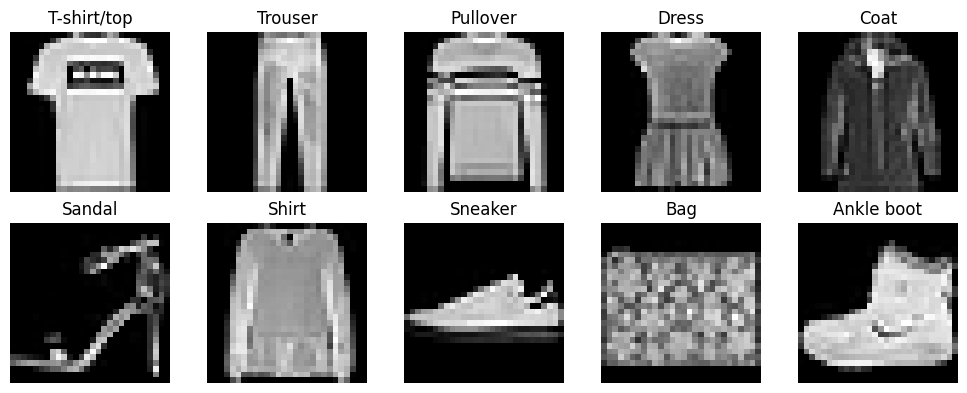

In [ ]:
# Lista com os nomes das classes do conjunto de dados Fashion MNIST, na mesma ordem dos índices
classes = ["T-shirt/top", "Trouser", "Pullover", "Dress", "Coat", "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"]

# Dicionário para armazenar um exemplo por classe
examples = {}

# Itera sobre o dataset até obter um exemplo de cada classe
for img, label in training_data:
    if label not in examples:
        examples[label] = img.squeeze()  # remove o canal extra (1, 28, 28) -> (28, 28)
    if len(examples) == 10:
        break

# Plota os exemplos
plt.figure(figsize=(10, 4))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(examples[i], cmap="gray")
    plt.title(classes[i])
    plt.axis("off")
plt.tight_layout()
plt.show()

In [ ]:
batch_size = 32                                                                                     # Define o tamanho do lote
train_dataloader = DataLoader(training_data, batch_size=batch_size, shuffle=True, drop_last=True)   # Cria o DataLoader para o conjunto de treinamento
test_dataloader = DataLoader(test_data, batch_size=batch_size)                                      # Cria o DataLoader para o conjunto de teste

# Itera sobre o DataLoader de teste para visualizar as formas dos dados
for X, y in test_dataloader:
    # Exibe a forma e o tipo do tensor de imagens
    # N = tamanho do lote, C = canais (1 para imagens em tons de cinza), H = altura, W = largura
    print(f"Forma de X [N, C, H, W]: {X.shape}, Tipo de dados em X: {X.dtype}")

    # Exibe a forma e o tipo dos rótulos (labels)
    print(f"Forma de y [N, ] : {y.shape}, Tipo de dados em y: {y.dtype}")

    break  # Encerra o loop após a primeira iteração, apenas para inspeção dos dados

Forma de X [N, C, H, W]: torch.Size([32, 1, 28, 28]), Tipo de dados em X: torch.float32
Forma de y [N, ] : torch.Size([32]), Tipo de dados em y: torch.int64


## Redes Neurais

### Transposed Convolution

In [ ]:
Image(url='https://raw.githubusercontent.com/rasbt/machine-learning-book/main/ch17/figures/17_10.png', width=600)

In [ ]:
Image(url=' https://d2l.ai/_images/trans_conv.svg', width=600)  # Fonte: Dive into Deep Learning (https://d2l.ai/chapter_computer-vision/transposed-conv.html)

### Batch Normalization

In [ ]:
Image(url='https://raw.githubusercontent.com/rasbt/machine-learning-book/main/ch17/figures/17_11.png', width=700)

### Gerador

In [ ]:
class Gerador(nn.Module):
    def __init__(self, z_dim=100):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(z_dim, 7*7*128),
            nn.Unflatten(dim=1, unflattened_size=(128, 7, 7)),
            nn.BatchNorm2d(128),
            nn.ConvTranspose2d(128, 64, kernel_size=5, stride=2, padding=2, output_padding=1),
            nn.ReLU(True),
            nn.BatchNorm2d(64),
            nn.ConvTranspose2d(64, 1, kernel_size=5, stride=2, padding=2, output_padding=1),
            nn.Tanh()
        )

    def forward(self, z):
        return self.net(z)

### Discriminador

In [ ]:
class Discriminador(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(1, 64, kernel_size=5, stride=2, padding=2),
            nn.LeakyReLU(negative_slope=0.2),
            nn.Dropout(p=0.4),
            nn.Conv2d(64, 128, kernel_size=5, stride=2, padding=2),
            nn.LeakyReLU(negative_slope=0.2),
            nn.Dropout(p=0.4),
            nn.Flatten(),
            nn.Linear(7*7*128, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.net(x)

## Treinamento

In [ ]:
def train_dcgan(dataloader, gerador, discriminador, loss_fn, opt_gerador, opt_discriminador, device, epoch, z_dim):
    gerador.train()         # Coloca o modelo em modo de treinamento (ativa dropout, batchnorm, etc., se houver)
    discriminador.train()   # Coloca o modelo em modo de treinamento (ativa dropout, batchnorm, etc., se houver)

    size = len(dataloader.dataset)

    for batch, (real_data, _) in enumerate(dataloader):

        batch_size = real_data.shape[0]
        real_data = real_data.to(device)

        # ========================================
        # Treinamento do DISCRIMINADOR
        # ========================================

        # Gera rótulos para dados reais (1) e falsos (0)
        labels_reais = torch.ones((batch_size, 1), device=device)
        labels_falsos = torch.zeros((batch_size, 1), device=device)

        # Gera dados falsos a partir de ruído aleatório (distribuicão normal)
        z = torch.randn((batch_size, z_dim), device=device)
        dados_falsos = gerador(z)

        # Calcula a saída do discriminador para dados reais e falsos
        saida_reais = discriminador(real_data)
        saida_falsos = discriminador(dados_falsos.detach())  # detach() evita que os gradientes fluam para o gerador

        # Calcula a perda do discriminador
        perda_reais = loss_fn(saida_reais, labels_reais)
        perda_falsos = loss_fn(saida_falsos, labels_falsos)
        perda_discriminador = perda_reais + perda_falsos

        # Atualiza o discriminador
        opt_discriminador.zero_grad()
        perda_discriminador.backward()
        opt_discriminador.step()

        # ========================================
        # Treinamento do GERADOR
        # ========================================

        # Gera novos vetores latentes
        z = torch.randn((batch_size, z_dim), device=device)
        dados_falsos = gerador(z)

        # Queremos que o discriminador pense que os dados falsos são reais
        saida_falsos = discriminador(dados_falsos)
        perda_gerador = loss_fn(saida_falsos, labels_reais)  # usamos labels_reais aqui!

        # Atualiza o gerador
        opt_gerador.zero_grad()
        perda_gerador.backward()
        opt_gerador.step()

        # ========================================
        # Log de progresso
        # ========================================
        if batch % 100 == 0 or batch == len(dataloader) - 1:
            print(f"[Época {epoch:03d}] [Lote {batch:03d}/{len(dataloader)}] "
                  f"Perda D: {perda_discriminador.item():.4f} | Perda G: {perda_gerador.item():.4f}")


In [ ]:
# Define a função de gerar dados falsos de um vetor latente fixo
def gerar(gerador, device, z_dim=100):
    gerador.eval()                  # Coloca o modelo em modo de avaliação (desativa dropout, batchnorm, etc.)
    # Desativa o cálculo de gradientes para economizar memória e acelerar a execução
    with torch.no_grad():
      z = torch.zeros((1, z_dim), device=device)
      dados_falsos = gerador(z).detach().cpu().numpy().reshape(28,28)
    return dados_falsos

In [ ]:
z_dim = 100
# Inicializa os modelos
modelo_gerador = Gerador(z_dim)
# Imprime a arquitetura do modelo
print(modelo_gerador)
# Inicializa os modelos
modelo_discriminador = Discriminador()
# Imprime a arquitetura do modelo
print(modelo_discriminador)

# Opcional: tenta usar GPU se disponível
device = torch.accelerator.current_accelerator().type if torch.accelerator.is_available() else "cpu"
modelo_gerador.to(device)
modelo_discriminador.to(device)

# Exibe qual dispositivo está sendo utilizado
print(f"Usando {device}.")

# Otimizadores
lr_gerador = 1e-3         # taxa de aprendizagem do gerador
lr_discriminador = 1e-3   # learning rate do discriminador
optimizador_gerador = torch.optim.RMSprop(modelo_gerador.parameters(), lr=lr_gerador)
optimizador_discriminador = torch.optim.RMSprop(modelo_discriminador.parameters(), lr=lr_discriminador)

# Função de perda
loss_fn = nn.BCELoss()

Gerador(
  (net): Sequential(
    (0): Linear(in_features=100, out_features=6272, bias=True)
    (1): Unflatten(dim=1, unflattened_size=(128, 7, 7))
    (2): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (3): ConvTranspose2d(128, 64, kernel_size=(5, 5), stride=(2, 2), padding=(2, 2), output_padding=(1, 1))
    (4): ReLU(inplace=True)
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ConvTranspose2d(64, 1, kernel_size=(5, 5), stride=(2, 2), padding=(2, 2), output_padding=(1, 1))
    (7): Tanh()
  )
)
Discriminador(
  (net): Sequential(
    (0): Conv2d(1, 64, kernel_size=(5, 5), stride=(2, 2), padding=(2, 2))
    (1): LeakyReLU(negative_slope=0.2)
    (2): Dropout(p=0.4, inplace=False)
    (3): Conv2d(64, 128, kernel_size=(5, 5), stride=(2, 2), padding=(2, 2))
    (4): LeakyReLU(negative_slope=0.2)
    (5): Dropout(p=0.4, inplace=False)
    (6): Flatten(start_dim=1, end_dim=-1)
    (7): Linear(in_featu

In [ ]:
num_epochs = 10  # Define o número total de épocas (iterações completas sobre o conjunto de dados de treinamento)
evolução_dado_falso = []
for epoca in range(1, num_epochs + 1):
    train_dcgan(
        dataloader=train_dataloader,
        gerador=modelo_gerador,
        discriminador=modelo_discriminador,
        loss_fn=loss_fn,
        opt_gerador=optimizador_gerador,
        opt_discriminador=optimizador_discriminador,
        device=device,
        epoch=epoca,
        z_dim=z_dim
    )
    if epoca % 2 == 0 or epoca == 1:
      evolução_dado_falso.append(gerar(gerador=modelo_gerador, device=device, z_dim=z_dim))
print("Fim!")  # Exibe mensagem final indicando que o treinamento terminou

[Época 001] [Lote 000/1875] Perda D: 1.3942 | Perda G: 3.2143
[Época 001] [Lote 100/1875] Perda D: 0.5672 | Perda G: 1.5572
[Época 001] [Lote 200/1875] Perda D: 1.1194 | Perda G: 2.0407
[Época 001] [Lote 300/1875] Perda D: 0.9642 | Perda G: 1.0181
[Época 001] [Lote 400/1875] Perda D: 1.2210 | Perda G: 0.8252
[Época 001] [Lote 500/1875] Perda D: 1.0209 | Perda G: 1.7378
[Época 001] [Lote 600/1875] Perda D: 1.0270 | Perda G: 0.9484
[Época 001] [Lote 700/1875] Perda D: 0.8913 | Perda G: 1.2048
[Época 001] [Lote 800/1875] Perda D: 1.1799 | Perda G: 2.6567
[Época 001] [Lote 900/1875] Perda D: 0.7481 | Perda G: 1.3358
[Época 001] [Lote 1000/1875] Perda D: 1.0477 | Perda G: 1.6667
[Época 001] [Lote 1100/1875] Perda D: 0.6498 | Perda G: 1.7361
[Época 001] [Lote 1200/1875] Perda D: 0.7699 | Perda G: 1.9362
[Época 001] [Lote 1300/1875] Perda D: 0.9273 | Perda G: 1.8952
[Época 001] [Lote 1400/1875] Perda D: 0.8625 | Perda G: 2.1167
[Época 001] [Lote 1500/1875] Perda D: 1.4319 | Perda G: 0.9858
[É

## Resultados

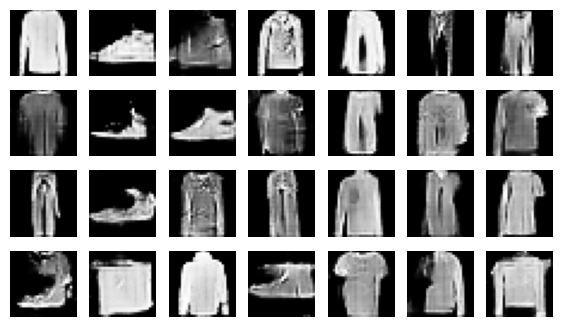

In [ ]:
# Define a função de gerar dados falsos de um vetores latentes aleatorios
def gerar_aleatorio(gerador, device, z_dim=z_dim, n_images=20):
    gerador.eval()                  # Coloca o modelo em modo de avaliação (desativa dropout, batchnorm, etc.)
    z = torch.randn((n_images, z_dim), device=device)
    # Desativa o cálculo de gradientes para economizar memória e acelerar a execução
    with torch.no_grad():
      dados_falsos = modelo_gerador(z).detach().cpu().numpy()
    return dados_falsos

# Função para plotar várias imagens em um grid
def plot_multiple_images(imagens, n_cols=7):
    n_cols = n_cols
    n_rows = (len(imagens) - 1) // n_cols + 1
    plt.figure(figsize=(n_cols, n_rows))
    for index, img in enumerate(imagens):
        plt.subplot(n_rows, n_cols, index + 1)
        plt.imshow(img.reshape(28, 28), cmap="gray")
        plt.axis("off")
    plt.show()

# Gera um lote com imagens falsas
imagens = gerar_aleatorio(modelo_gerador, device, z_dim=z_dim, n_images=28)

# Chama a função para plotar as imagens
plot_multiple_images(imagens, n_cols=7)

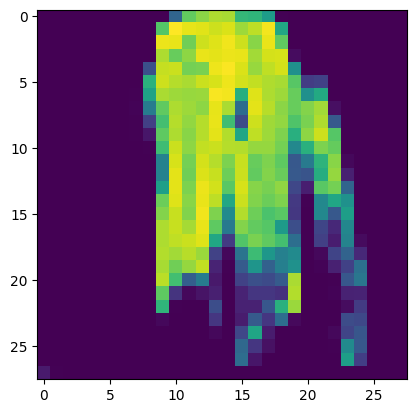

In [ ]:
z = torch.randn((1, z_dim), device=device)
dados_falsos = modelo_gerador(z).detach()
plt.figure()
plt.imshow(dados_falsos.detach().cpu().numpy().reshape(28,28))
plt.show()

## Evolução das saídas do gerador para um vetor latente fixo durante o treinamento

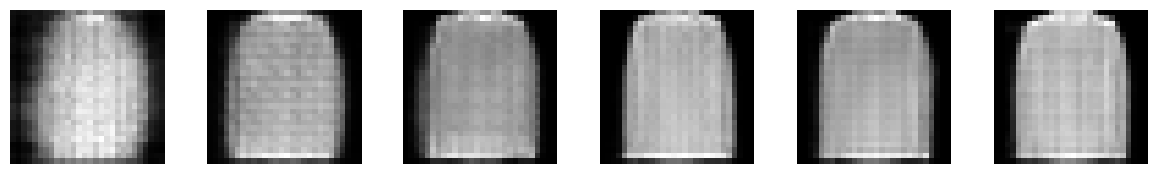

In [ ]:
# Lista com imagens
imagens = evolução_dado_falso

# Cria subplots (1 linha, -1 colunas)
fig, axes = plt.subplots(1, len(evolução_dado_falso), figsize=(15, 2))

# Itera por cada subplot e mostra a imagem
for ax, img in zip(axes, imagens):
    ax.imshow(img, cmap='gray')    # 1 = preto, 0 = branco
    ax.axis('off')                 # Remove ticks dos eixos

plt.subplots_adjust(wspace=0.1)    # ajusta o espacamento entre subplots

plt.show()

## Interpolação no espaço latente

In [ ]:
Image(url='https://raw.githubusercontent.com/mbernste/mbernste.github.io/master/images/VAE_interpolate_3_to_7.png', width=600)

In [ ]:
# Função que interpola entre dois vetores latentes e gera imagens correspondentes
def interpolar_espaco_latente(gerador, z_dim=100, steps=10, device='cpu'):

    # Gera dois vetores latentes aleatórios
    z1 = torch.randn((1, z_dim), device=device)
    z2 = torch.randn((1, z_dim), device=device)

    gerador.eval()  # Coloca o gerador em modo de avaliação

    alpha_valores = torch.linspace(0, 1, steps).to(device)  # Valores de interpolação entre 0 e 1
    imagens_interpoladas = []

    for alpha in alpha_valores:
        # Interpola linearmente entre z1 e z2: z_interp = (1 - alpha) * z1 + alpha * z2 , alpha em [0, 1]
        z_interp = (1 - alpha) * z1 + alpha * z2

        with torch.no_grad():  # Evita calcular gradientes (modo de inferência)
            imagem_gerada = gerador(z_interp.to(device)).cpu()

        # Remove dimensões extras e converte para numpy
        imagens_interpoladas.append(imagem_gerada.squeeze().numpy())

    return imagens_interpoladas

# Função para plotar uma lista de imagens em uma única linha
def plotar_imagens(imagens):
    fig, eixos = plt.subplots(1, len(imagens), figsize=(len(imagens), 1.5))
    for ax, img in zip(eixos, imagens):
        ax.imshow(img.reshape(28, 28), cmap='gray')  # Mostra a imagem em escala de cinza
        ax.axis('off')                               # Remove os eixos para visualização limpa
    plt.tight_layout()
    plt.show()

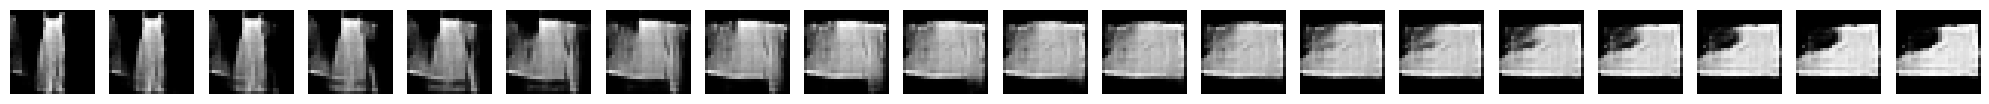

In [ ]:
# Gera imagens interpoladas entre z1 e z2
imagens = interpolar_espaco_latente(modelo_gerador, z_dim=z_dim, steps=20, device=device)

# Plota as imagens lado a lado
plotar_imagens(imagens)

# Tarefa (em duplas)

**Investigar o efeito da capacidade das redes, da taxa de aprendizado e do otimizador em uma DCGAN treinada com dígitos MNIST**

Utilize o código acima como base e adapte-o para o seguinte problema:

1. Substitua o conjunto *Fashion-MNIST* pelo conjunto de dígitos *MNIST*, disponível em [`torchvision.datasets`](https://docs.pytorch.org/vision/stable/generated/torchvision.datasets.MNIST.html#torchvision.datasets.MNIST):

```python
training_data = datasets.MNIST(root="data", train=True,  download=True, transform=transform)
test_data     = datasets.MNIST(root="data", train=False, download=True, transform=transform)
```

**Obs.**: mantenha a normalização para o intervalo [-1, 1] já usada no `transform`, pois ela é compatível com a `Tanh` na saída do gerador.

2. Treine a **configuração base** (gerador, discriminador e hiperparâmetros do código acima) no MNIST. Este será o experimento de referência para todas as comparações seguintes.

3. Reduza a **capacidade do gerador**, mantendo o discriminador base. Por exemplo:
   - removendo camadas;
   - reduzindo o número de kernels (filtros) por camada.

4. Reduza a **capacidade do discriminador**, mantendo o gerador base. Por exemplo:
   - removendo camadas;
   - reduzindo o número de kernels (filtros) por camada.

5. Varie as **taxas de aprendizado** do gerador e do discriminador de forma independente, mantendo as arquiteturas base. Teste ao menos três combinações, incluindo um caso com `lr_gerador >> lr_discriminador` e outro com `lr_gerador << lr_discriminador`.

6. Teste **um otimizador adicional** (`SGD`) no lugar do `RMSprop`, mantendo os demais hiperparâmetros da configuração base.

7. Para cada experimento, registre:
   - as perdas do gerador e do discriminador ao longo das épocas (adapte a função `train_dcgan` para acumular e retornar as perdas médias por época);
   - uma grade de amostras geradas a partir de vetores latentes aleatórios ao final do treinamento;
   - a evolução das saídas do gerador para um **vetor latente fixo** ao longo das épocas.

8. Realize a **interpolação no espaço latente** entre dois vetores latentes para a **configuração base**.

**Para que os experimentos sejam comparáveis, treine todos com o mesmo número de épocas, o mesmo `batch_size`, o mesmo `z_dim` e a mesma semente aleatória.** Altere apenas o fator sob investigação em cada experimento.

**Entregáveis:**

Os entregáveis são **cumulativos ao longo da Unidade 1**. Ao final da unidade,
você entregará **apenas dois arquivos**, reunindo todos os laboratórios:

1. **Notebook** (`.ipynb`) — um único notebook com o código de todos os
   laboratórios da unidade, cada um em sua própria seção, na ordem em que foram
   realizados.

   O notebook deve **executar do início ao fim sem erros**, em um kernel novo,
   com *Restart & Run All*. Antes de entregar, execute-o dessa forma e confirme
   que todas as células rodam na ordem em que aparecem e que as saídas exibidas
   correspondem a essa execução. Notebooks que não executarem por completo serão
   penalizados.

2. **Relatório** (`.pdf`) — um único PDF, também organizado em seções, uma por
   laboratório.

Este laboratório corresponde à **Seção 2 — DCGAN**, que deve conter:

- **Setup**: dados utilizados (conjunto, normalização aplicada e tamanho do
  lote), arquiteturas do gerador e do discriminador da configuração base, e
  hiperparâmetros (função de perda, otimizador, taxas de aprendizado, dimensão
  do vetor de ruído e número de épocas). Apresente também uma tabela listando os
  experimentos realizados e, em cada um, o que foi alterado em relação à
  configuração base.
- **Resultados**: para cada experimento,
  - curvas de perda do gerador e do discriminador ao longo das épocas;
  - grade de amostras geradas ao final do treinamento;
  - evolução das saídas do gerador para um vetor latente fixo, incluindo o
    início, o meio e o final do treinamento;
  - imagens da interpolação no espaço latente para o melhor e o pior modelo.
- **Análise**: texto breve (5-10 linhas) discutindo, a partir da inspeção visual
  das figuras, o efeito de reduzir a capacidade do gerador e do discriminador
  sobre a qualidade das amostras, o efeito do desbalanceamento entre as taxas de
  aprendizado, e o que o comportamento das curvas de perda sugere sobre a
  estabilidade do treinamento em cada caso. Comente se houve indícios de colapso
  de modos [*mode collapse*] ou de um discriminador dominante.

Nos próximos laboratórios da unidade, acrescente uma nova seção a cada arquivo,
preservando as anteriores.

O relatório **não** deve conter código.

A entrega é **única por grupo**. Identifique os integrantes no início do
notebook e na primeira página do relatório.